# 05 — Modelagem

> **Etapa 4 do refactor.** Treina modelos de classificação sobre as **62
> features finais** (24 tabulares + 38 PDI), compara desempenho entre eles
> em validação, e faz uma única avaliação no test set com o melhor modelo.

## O que este notebook faz

1. Carrega os parquets do nb04 (`train/val/test.parquet`) já normalizados e splitados
2. Estabelece um **baseline burro** (`DummyClassifier`) como piso de comparação
3. Treina **Random Forest** com `class_weight='balanced'` — baseline robusto de árvore
4. Treina **XGBoost** com `sample_weight` — geralmente o mais forte em tabular
5. Compara os dois no **val set**, escolhe o melhor
6. Avalia o vencedor **uma única vez** no test set
7. Analisa **feature importance** e **matriz de confusão** do modelo final

## O que este notebook NÃO faz

- Não treina com tabular/PDI separado (já discutido: treina com as duas fontes juntas)
- Não faz tuning exaustivo de hiperparâmetros (defaults + ajustes mínimos)
- Não testa CNN nem deep learning (pipeline clássico)
- Não faz análise de erros aprofundada (fica para o nb06)

## Estratégia contra o desbalanceamento

`class_weight='balanced'` no RF + `sample_weight` derivado dos class_weights no XGBoost.
**Zero modificação nos dados** — os 33 MELs do treino continuam 33. A compensação
acontece na função de perda, não via oversampling/SMOTE.


## 1. Setup

In [1]:
from pathlib import Path
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score, precision_score,
    classification_report, confusion_matrix,
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

ROOT     = Path('..').resolve()
FEAT_DIR = ROOT / 'data' / 'processed' / 'features'
META_DIR = ROOT / 'data' / 'processed' / 'metadata'
OUT_DIR  = ROOT / 'models'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

print('features dir:', FEAT_DIR)
print('models out  :', OUT_DIR)


features dir: /home/fonsek/CODE/pad-ufes-skin-classification/data/processed/features
models out  : /home/fonsek/CODE/pad-ufes-skin-classification/models


## 2. Carregamento dos dados

Carregamos `train/val/test.parquet` do nb04, a lista de features, os pesos de
classe do nb02 e o `LabelEncoder` para reportar métricas com nomes de classe.


In [2]:
train = pd.read_parquet(FEAT_DIR / 'train.parquet')
val   = pd.read_parquet(FEAT_DIR / 'val.parquet')
test  = pd.read_parquet(FEAT_DIR / 'test.parquet')

names = json.load(open(FEAT_DIR / 'feature_names.json'))
feature_cols = names['all']   # 62 features

class_weights = joblib.load(META_DIR / 'class_weights.joblib')
le_target     = joblib.load(META_DIR / 'label_encoder.joblib')
class_names   = list(le_target.classes_)   # ['ACK','BCC','MEL','NEV','SCC','SEK']

X_train, y_train = train[feature_cols].values, train['y'].values
X_val,   y_val   = val[feature_cols].values,   val['y'].values
X_test,  y_test  = test[feature_cols].values,  test['y'].values

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val  : {X_val.shape}  y_val  : {y_val.shape}')
print(f'X_test : {X_test.shape}  y_test : {y_test.shape}')
print(f'\nClasses: {class_names}')
print(f'class_weights: {class_weights}')
print(f'\nDistribuição treino:')
for i, cls in enumerate(class_names):
    n = int((y_train == i).sum())
    print(f'  {cls}: {n:4d}  peso={class_weights[i]:.2f}')


X_train: (1470, 62)  y_train: (1470,)
X_val  : (368, 62)  y_val  : (368,)
X_test : (460, 62)  y_test : (460,)

Classes: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
class_weights: {0: 0.5246252676659529, 1: 0.45286506469500926, 2: 7.424242424242424, 3: 1.5705128205128205, 4: 1.991869918699187, 5: 1.6333333333333333}

Distribuição treino:
  ACK:  467  peso=0.52
  BCC:  541  peso=0.45
  MEL:   33  peso=7.42
  NEV:  156  peso=1.57
  SCC:  123  peso=1.99
  SEK:  150  peso=1.63


## 3. Helpers de avaliação

Função única que imprime **F1-macro**, **acurácia**, **recall por classe**
(especialmente MEL), e retorna um dicionário com as métricas-chave para
comparação posterior.


In [3]:
def evaluate(model, X, y, name, split_name='val'):
    '''Avalia um modelo e retorna métricas.'''
    y_pred = model.predict(X)

    f1_macro = f1_score(y, y_pred, average='macro', zero_division=0)
    acc      = accuracy_score(y, y_pred)
    recall_per_class = recall_score(y, y_pred, average=None, zero_division=0)

    # Recall do MEL especificamente (classe 2)
    mel_idx = class_names.index('MEL')
    recall_mel = recall_per_class[mel_idx]

    print(f'\n{"="*60}')
    print(f'{name} — {split_name}')
    print(f'{"="*60}')
    print(f'F1-macro    : {f1_macro:.4f}')
    print(f'Accuracy    : {acc:.4f}')
    print(f'Recall MEL  : {recall_mel:.4f}  ← classe crítica')
    print(f'\nClassification report:')
    print(classification_report(y, y_pred, target_names=class_names,
                                zero_division=0, digits=3))

    return {
        'name': name,
        'split': split_name,
        'f1_macro': f1_macro,
        'accuracy': acc,
        'recall_mel': recall_mel,
        'recall_per_class': recall_per_class,
        'y_pred': y_pred,
    }


def plot_confusion(y_true, y_pred, title):
    '''Matriz de confusão com números absolutos + normalizada.'''
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, matrix, subtitle, fmt in [
        (axes[0], cm,      'Contagem absoluta', 'd'),
        (axes[1], cm_norm, 'Normalizada por classe verdadeira', '.2f'),
    ]:
        im = ax.imshow(matrix, cmap='Blues', aspect='auto')
        ax.set_xticks(range(6)); ax.set_yticks(range(6))
        ax.set_xticklabels(class_names)
        ax.set_yticklabels(class_names)
        ax.set_xlabel('Predito')
        ax.set_ylabel('Verdadeiro')
        ax.set_title(subtitle)
        for i in range(6):
            for j in range(6):
                val = matrix[i, j]
                color = 'white' if matrix[i, j] > matrix.max() * 0.5 else 'black'
                ax.text(j, i, format(val, fmt), ha='center', va='center',
                        color=color, fontsize=9)
        plt.colorbar(im, ax=ax, shrink=0.7)

    plt.suptitle(title, fontsize=12)
    plt.tight_layout(); plt.show()


## 4. Baseline burro — `DummyClassifier`

Antes de qualquer modelo real, estabelece o **piso absoluto** de comparação.
O DummyClassifier "estratificado" prevê classes aleatoriamente respeitando
a distribuição do treino. Qualquer modelo real precisa bater esse piso —
senão, está pior que o acaso.


In [4]:
dummy = DummyClassifier(strategy='stratified', random_state=SEED)
dummy.fit(X_train, y_train)
res_dummy = evaluate(dummy, X_val, y_val, 'DummyClassifier (stratified)')



DummyClassifier (stratified) — val
F1-macro    : 0.1699
Accuracy    : 0.2690
Recall MEL  : 0.0000  ← classe crítica

Classification report:
              precision    recall  f1-score   support

         ACK      0.308     0.308     0.308       117
         BCC      0.370     0.378     0.374       135
         MEL      0.000     0.000     0.000         9
         NEV      0.171     0.154     0.162        39
         SCC      0.094     0.100     0.097        30
         SEK      0.079     0.079     0.079        38

    accuracy                          0.269       368
   macro avg      0.170     0.170     0.170       368
weighted avg      0.267     0.269     0.268       368



## 5. Modelo 1 — Random Forest

Baseline robusto de árvore. `class_weight='balanced'` nativo do sklearn
compensa o desbalanceamento. Hiperparâmetros razoáveis para este tamanho
de dataset:

- `n_estimators=500` — suficiente para RF estabilizar
- `max_depth=None` — deixa árvores crescerem até puras (RF regulariza via média)
- `min_samples_leaf=2` — evita folhas com 1 amostra (sobreajuste)
- `max_features='sqrt'` — padrão para classificação (√62 ≈ 8 features por split)
- `class_weight='balanced'` — compensa o imbalance 16×
- `n_jobs=-1` — paralelismo total


RF treinado em 0.8s

Random Forest — val
F1-macro    : 0.5461
Accuracy    : 0.7310
Recall MEL  : 0.2222  ← classe crítica

Classification report:
              precision    recall  f1-score   support

         ACK      0.792     0.846     0.818       117
         BCC      0.695     0.911     0.788       135
         MEL      1.000     0.222     0.364         9
         NEV      0.923     0.615     0.738        39
         SCC      0.000     0.000     0.000        30
         SEK      0.583     0.553     0.568        38

    accuracy                          0.731       368
   macro avg      0.666     0.525     0.546       368
weighted avg      0.689     0.731     0.695       368



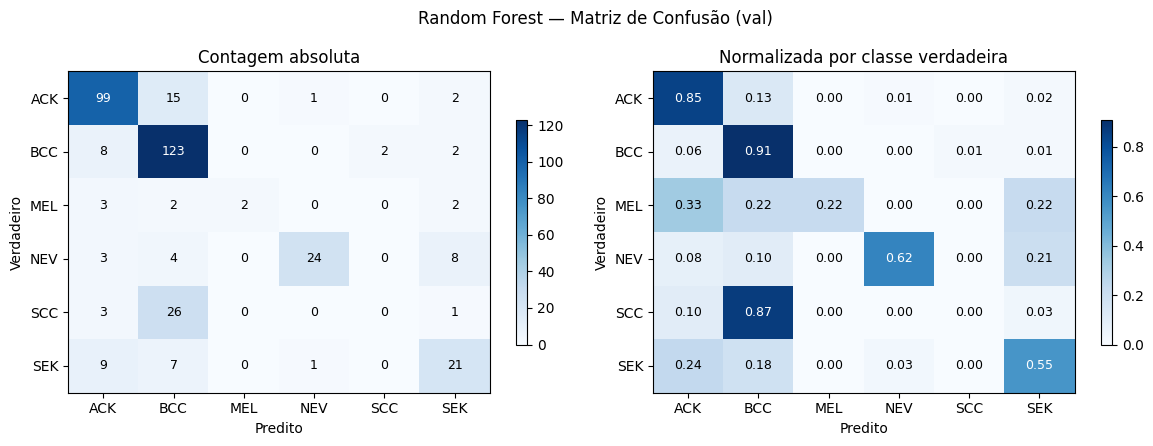

In [5]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)

t0 = time.time()
rf.fit(X_train, y_train)
dt_rf = time.time() - t0
print(f'RF treinado em {dt_rf:.1f}s')

res_rf_val = evaluate(rf, X_val, y_val, 'Random Forest')
plot_confusion(y_val, res_rf_val['y_pred'],
               'Random Forest — Matriz de Confusão (val)')


## 6. Modelo 2 — XGBoost

**XGBoost** (Extreme Gradient Boosting) é historicamente o modelo mais forte
para dados tabulares. Diferente do RF (que faz *bagging* de árvores independentes),
XGBoost faz *boosting* — cada árvore corrige os erros das anteriores.

**Tratamento do desbalanceamento:** XGBoost multiclasse não tem `class_weight`
nativo como o sklearn, então usamos `sample_weight` — um vetor onde cada amostra
recebe o peso da sua classe. É equivalente matemático a `class_weight='balanced'`
do sklearn.

**Hiperparâmetros:**
- `n_estimators=500` + `early_stopping_rounds=30` — para quando val para de melhorar
- `max_depth=6` — árvores mais rasas que RF (boosting compensa)
- `learning_rate=0.05` — passo conservador
- `subsample=0.8`, `colsample_bytree=0.8` — regularização estocástica
- `objective='multi:softprob'` — multiclasse probabilístico


XGBoost treinado em 1.3s  (best_iter=58)

XGBoost — val
F1-macro    : 0.5704
Accuracy    : 0.6929
Recall MEL  : 0.3333  ← classe crítica

Classification report:
              precision    recall  f1-score   support

         ACK      0.850     0.778     0.812       117
         BCC      0.750     0.756     0.753       135
         MEL      0.500     0.333     0.400         9
         NEV      0.765     0.667     0.712        39
         SCC      0.148     0.133     0.140        30
         SEK      0.500     0.763     0.604        38

    accuracy                          0.693       368
   macro avg      0.586     0.572     0.570       368
weighted avg      0.703     0.693     0.694       368



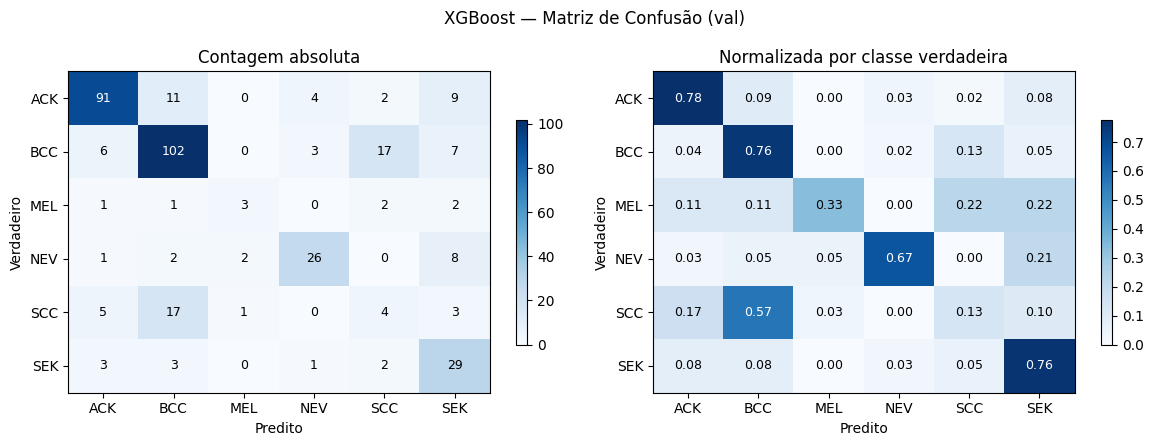

In [6]:
# Gerar sample_weight a partir dos class_weights
sample_weight_train = np.array([class_weights[int(y)] for y in y_train])
sample_weight_val   = np.array([class_weights[int(y)] for y in y_val])

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=6,
    eval_metric='mlogloss',
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

t0 = time.time()
xgb.fit(
    X_train, y_train,
    sample_weight=sample_weight_train,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[sample_weight_val],
    verbose=False,
)
dt_xgb = time.time() - t0
print(f'XGBoost treinado em {dt_xgb:.1f}s  (best_iter={xgb.best_iteration})')

res_xgb_val = evaluate(xgb, X_val, y_val, 'XGBoost')
plot_confusion(y_val, res_xgb_val['y_pred'],
               'XGBoost — Matriz de Confusão (val)')


## 7. Comparação RF × XGBoost (val)

Tabela lado-a-lado das métricas principais. **A decisão "qual modelo levar para
o test" é baseada no desempenho em val, nunca no test.**


In [7]:
comparison = pd.DataFrame([
    {
        'modelo': 'Dummy (stratified)',
        'f1_macro': res_dummy['f1_macro'],
        'accuracy': res_dummy['accuracy'],
        'recall_MEL': res_dummy['recall_mel'],
    },
    {
        'modelo': 'Random Forest',
        'f1_macro': res_rf_val['f1_macro'],
        'accuracy': res_rf_val['accuracy'],
        'recall_MEL': res_rf_val['recall_mel'],
    },
    {
        'modelo': 'XGBoost',
        'f1_macro': res_xgb_val['f1_macro'],
        'accuracy': res_xgb_val['accuracy'],
        'recall_MEL': res_xgb_val['recall_mel'],
    },
])
comparison = comparison.set_index('modelo').round(4)
print(comparison.to_string())

# Recall por classe lado-a-lado
recall_cmp = pd.DataFrame({
    'RF':      res_rf_val['recall_per_class'],
    'XGBoost': res_xgb_val['recall_per_class'],
}, index=class_names).round(3)
print('\nRecall por classe (val):')
print(recall_cmp.to_string())

# Escolhe o melhor por F1-macro (tie-break: recall de MEL)
best_name = comparison[['f1_macro']].idxmax().iloc[0]
if comparison.loc['Random Forest', 'f1_macro'] == comparison.loc['XGBoost', 'f1_macro']:
    best_name = 'Random Forest' if res_rf_val['recall_mel'] >= res_xgb_val['recall_mel'] else 'XGBoost'

print(f'\n🏆 Modelo vencedor: {best_name}')
best_model = rf if best_name == 'Random Forest' else xgb


                    f1_macro  accuracy  recall_MEL
modelo                                            
Dummy (stratified)    0.1699    0.2690      0.0000
Random Forest         0.5461    0.7310      0.2222
XGBoost               0.5704    0.6929      0.3333

Recall por classe (val):
        RF  XGBoost
ACK  0.846    0.778
BCC  0.911    0.756
MEL  0.222    0.333
NEV  0.615    0.667
SCC  0.000    0.133
SEK  0.553    0.763

🏆 Modelo vencedor: XGBoost


## 8. Avaliação final no TEST set

**Esse é o único momento** em todo o notebook que tocamos no test. O modelo
já foi escolhido no passo anterior baseado no val. O test serve apenas para
reportar a métrica final "honesta" — nunca para escolher modelo, ajustar
hiperparâmetro ou decidir threshold.



XGBoost — TEST
F1-macro    : 0.5494
Accuracy    : 0.6913
Recall MEL  : 0.1000  ← classe crítica

Classification report:
              precision    recall  f1-score   support

         ACK      0.833     0.719     0.772       146
         BCC      0.795     0.757     0.776       169
         MEL      0.250     0.100     0.143        10
         NEV      0.714     0.918     0.804        49
         SCC      0.306     0.385     0.341        39
         SEK      0.421     0.511     0.462        47

    accuracy                          0.691       460
   macro avg      0.553     0.565     0.549       460
weighted avg      0.707     0.691     0.695       460



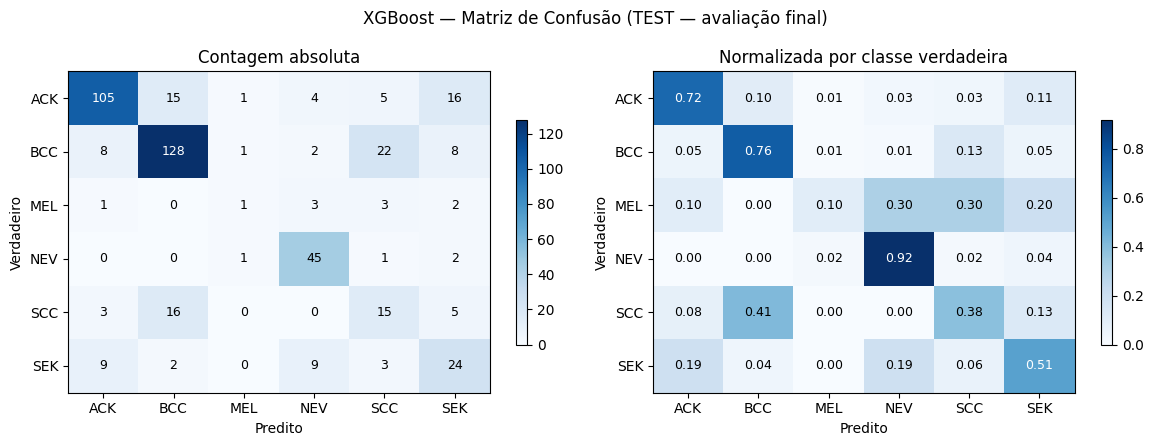


Gap train / val / test — XGBoost
  F1-macro train: 0.9579
  F1-macro val  : 0.5704  (gap train-val = +0.3875)
  F1-macro test : 0.5494  (gap val-test   = +0.0209)
  ⚠️  Gap train-val grande → provável overfit


In [8]:
res_test = evaluate(best_model, X_test, y_test, best_name, split_name='TEST')
plot_confusion(y_test, res_test['y_pred'],
               f'{best_name} — Matriz de Confusão (TEST — avaliação final)')

# Summary gap train/val/test para detectar overfit
y_train_pred = best_model.predict(X_train)
f1_train = f1_score(y_train, y_train_pred, average='macro')
f1_val   = res_rf_val['f1_macro'] if best_name == 'Random Forest' else res_xgb_val['f1_macro']
f1_test  = res_test['f1_macro']

print('\n' + '=' * 60)
print(f'Gap train / val / test — {best_name}')
print('=' * 60)
print(f'  F1-macro train: {f1_train:.4f}')
print(f'  F1-macro val  : {f1_val:.4f}  (gap train-val = {f1_train-f1_val:+.4f})')
print(f'  F1-macro test : {f1_test:.4f}  (gap val-test   = {f1_val-f1_test:+.4f})')
if f1_train - f1_val > 0.15:
    print('  ⚠️  Gap train-val grande → provável overfit')
else:
    print('  ✅ Gap train-val aceitável')


## 9. Feature importance do modelo vencedor

Quais features o modelo mais usou para decidir? Se as features clinicamente
importantes (`lab_a_std`, `shape_asymmetry_*`, sintomas ABCDE) estão no topo,
o modelo aprendeu o que deveria. Se aparecerem features estranhas no topo,
pode haver atalho estatístico (leak residual).


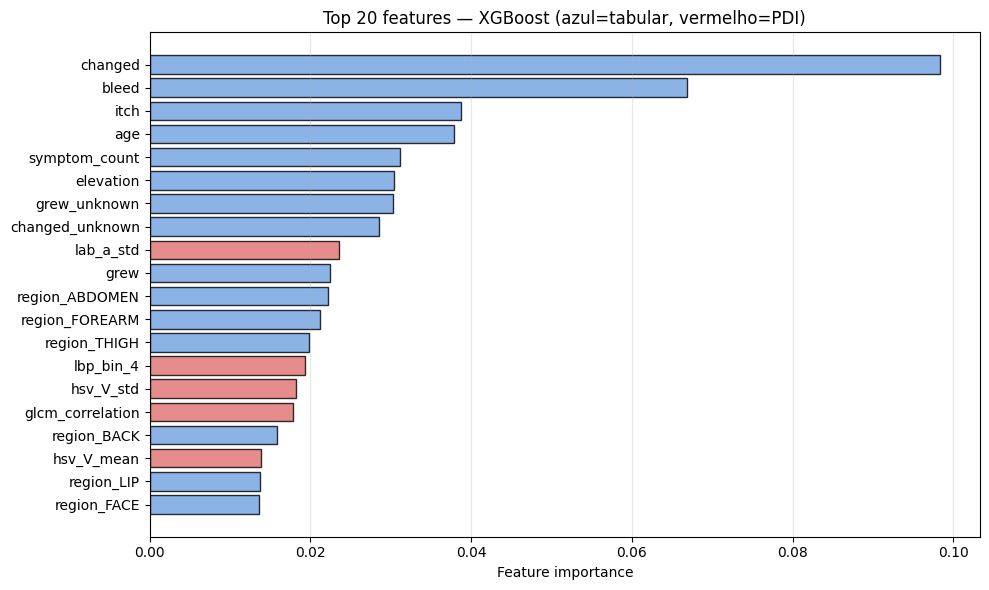


Top 20: 15 tabulares + 5 PDI

Top 10 features:
   1. changed                        TAB  0.0984
   2. bleed                          TAB  0.0668
   3. itch                           TAB  0.0387
   4. age                            TAB  0.0378
   5. symptom_count                  TAB  0.0311
   6. elevation                      TAB  0.0304
   7. grew_unknown                   TAB  0.0303
   8. changed_unknown                TAB  0.0285
   9. lab_a_std                      PDI  0.0235
  10. grew                           TAB  0.0225


In [9]:
importances = best_model.feature_importances_
fi = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
top20 = fi.head(20)

# Cor por origem: TAB ou PDI
tab_set = set(names['tabular'])
colors = ['#70a0e0' if f in tab_set else '#e07070' for f in top20.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20.index[::-1], top20.values[::-1],
        color=colors[::-1], edgecolor='black', alpha=0.8)
ax.set_xlabel('Feature importance')
ax.set_title(f'Top 20 features — {best_name} (azul=tabular, vermelho=PDI)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

# Quantas TAB vs PDI no top 20
n_tab = sum(1 for f in top20.index if f in tab_set)
n_pdi = 20 - n_tab
print(f'\nTop 20: {n_tab} tabulares + {n_pdi} PDI')
print(f'\nTop 10 features:')
for i, (name, imp) in enumerate(fi.head(10).items(), 1):
    origin = 'TAB' if name in tab_set else 'PDI'
    print(f'  {i:2d}. {name:30s} {origin}  {imp:.4f}')


## 10. Persistir o modelo final

Salva o modelo vencedor em disco para uso futuro. O notebook 06 (análise
de erros) vai carregar daqui.


In [10]:
model_path = OUT_DIR / f'{best_name.lower().replace(" ", "_")}_final.joblib'
joblib.dump(best_model, model_path)
print(f'✅ Modelo salvo: {model_path}')
print(f'   Tamanho: {model_path.stat().st_size/1024:.1f} KB')

# Metadados do experimento
experiment_info = {
    'best_model': best_name,
    'f1_macro_train': float(f1_train),
    'f1_macro_val':   float(f1_val),
    'f1_macro_test':  float(f1_test),
    'recall_mel_val':  float(res_rf_val['recall_mel'] if best_name=='Random Forest' else res_xgb_val['recall_mel']),
    'recall_mel_test': float(res_test['recall_mel']),
    'n_features': len(feature_cols),
    'n_train': len(X_train),
    'n_val':   len(X_val),
    'n_test':  len(X_test),
    'seed': SEED,
    'class_names': class_names,
}
with open(OUT_DIR / 'experiment_info.json', 'w') as f:
    json.dump(experiment_info, f, indent=2)
print(f'✅ Metadados salvos: {OUT_DIR / "experiment_info.json"}')


✅ Modelo salvo: /home/fonsek/CODE/pad-ufes-skin-classification/models/xgboost_final.joblib
   Tamanho: 1270.1 KB
✅ Metadados salvos: /home/fonsek/CODE/pad-ufes-skin-classification/models/experiment_info.json


## 11. Resumo

```
┌─ INPUT ────────────────────────────────────────────┐
│  data/processed/features/*.parquet                 │
│  62 features (24 tab + 38 PDI)                     │
│  1470 train / 368 val / 460 test                   │
└────────────────────────────────────────────────────┘
                        ↓
┌─ MODELAGEM ────────────────────────────────────────┐
│  Baseline:  DummyClassifier (stratified)           │
│  Modelo 1:  RandomForest (class_weight='balanced') │
│  Modelo 2:  XGBoost (sample_weight)                │
│                                                    │
│  Seleção: F1-macro no VAL (test trancado)          │
└────────────────────────────────────────────────────┘
                        ↓
┌─ OUTPUT ───────────────────────────────────────────┐
│  models/                                           │
│    {best_model}_final.joblib                       │
│    experiment_info.json                            │
│                                                    │
│  Métricas reportadas no TEST set                   │
└────────────────────────────────────────────────────┘
```

### Próximo notebook

`06_avaliacao_e_erros.ipynb` — análise de erros aprofundada: quais MELs
o modelo errou, confusões mais frequentes (SEK↔MEL?), SHAP values, e
análise por subgrupo (idade, região, fallback de segmentação).
